In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv("titanic.csv")

df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)



In [3]:
df


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [4]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

le1 = LabelEncoder()
le2 = LabelEncoder()

df['Sex'] = le1.fit_transform(df['Sex'])
df['Embarked'] = le2.fit_transform(df['Embarked'])

df.head()


C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_7560\3749674982.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_7560\3749674982.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [5]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)


In [6]:
X_train_g = X_train_full[['Age', 'Fare']]
X_test_g = X_test_full[['Age', 'Fare']]

gnb = GaussianNB()
gnb.fit(X_train_g, y_train)

y_pred_g = gnb.predict(X_test_g)

print("Accuracy:", accuracy_score(y_test, y_pred_g))
print(confusion_matrix(y_test, y_pred_g))
print(classification_report(y_test, y_pred_g))


Accuracy: 0.6536312849162011
[[103   7]
 [ 55  14]]
              precision    recall  f1-score   support

           0       0.65      0.94      0.77       110
           1       0.67      0.20      0.31        69

    accuracy                           0.65       179
   macro avg       0.66      0.57      0.54       179
weighted avg       0.66      0.65      0.59       179



In [7]:
X_train_b = X_train_full[['Sex', 'Embarked']]
X_test_b = X_test_full[['Sex', 'Embarked']]

X_train_b = (X_train_b > 0).astype(int)
X_test_b = (X_test_b > 0).astype(int)

bnb = BernoulliNB()
bnb.fit(X_train_b, y_train)

y_pred_b = bnb.predict(X_test_b)

print("Accuracy:", accuracy_score(y_test, y_pred_b))
print(confusion_matrix(y_test, y_pred_b))
print(classification_report(y_test, y_pred_b))


Accuracy: 0.776536312849162
[[94 16]
 [24 45]]
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



Text(0.5, 1.0, 'Confusion Matrix(Bernoulli)')

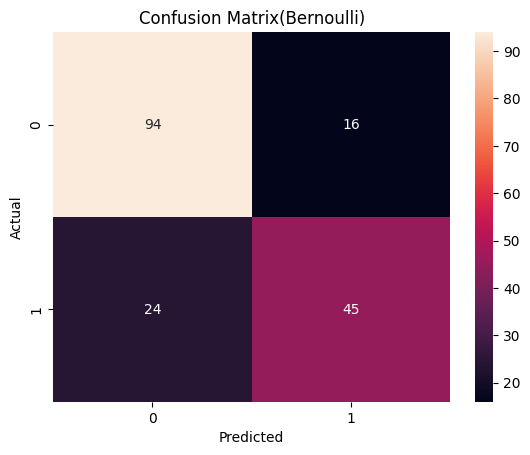

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred_b)
sns.heatmap(cm,annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix(Bernoulli)")

In [9]:
X_train_m = X_train_full[['SibSp', 'Parch']]
X_test_m = X_test_full[['SibSp', 'Parch']]

X_train_m = X_train_m.clip(lower=0)
X_test_m = X_test_m.clip(lower=0)

mnb = MultinomialNB()
mnb.fit(X_train_m, y_train)

y_pred_m = mnb.predict(X_test_m)

print("Accuracy:", accuracy_score(y_test, y_pred_m))
print(confusion_matrix(y_test, y_pred_m))
print(classification_report(y_test, y_pred_m))


Accuracy: 0.6089385474860335
[[107   3]
 [ 67   2]]
              precision    recall  f1-score   support

           0       0.61      0.97      0.75       110
           1       0.40      0.03      0.05        69

    accuracy                           0.61       179
   macro avg       0.51      0.50      0.40       179
weighted avg       0.53      0.61      0.48       179



In [10]:
print("GaussianNB:", accuracy_score(y_test, y_pred_g))
print("BernoulliNB:", accuracy_score(y_test, y_pred_b))
print("MultinomialNB:", accuracy_score(y_test, y_pred_m))


GaussianNB: 0.6536312849162011
BernoulliNB: 0.776536312849162
MultinomialNB: 0.6089385474860335
